In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.cluster import KMeans

In [2]:
n_samples = 500
seed = 30
random_state=170

In [3]:
# Generate synthetic datasets

blobs = datasets.make_blobs(
    n_samples=n_samples,
    centers=2,
    cluster_std=1,
    random_state=seed
)

crescents = datasets.make_moons(
    n_samples=n_samples,
    noise=0.05,
    random_state=seed
)

rings = datasets.make_circles(
    n_samples=500,
    factor=0.5,
    noise=0.05,
    random_state=30
)

varied_density = datasets.make_blobs(
    n_samples=n_samples,
    centers=2,
    cluster_std=[1, 2.5],
    random_state=random_state
)

varied_size = datasets.make_blobs(
    n_samples=[int(0.1 * n_samples), int(0.9 * n_samples)],
    cluster_std=[2, 2],
    random_state=random_state
)

x, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
original = (x, y)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
x_trans = np.dot(x, transformation)
transformed = (x_trans, y)

def svd_whiten(X):
    U, sigma, Vt = np.linalg.svd(X, full_matrices=False)
    # U and Vt are the singular matrices, and s contains the singular values.
    # Since the rows of both U and Vt are orthonormal vectors,
    #  U * Vt will be white
    X_white = np.dot(U, Vt)
    return X_white
x_svd = svd_whiten(transformed[0])
svd = (x_svd, y)

In [4]:
def plot_clusters(clusters, centers=None):
    """
    clusters (tuple[np.ndarray, iter]): A tuple of coordinates and cluster labels.
    centers (np.ndarray): An array of cluster centers where each row corresponds to a center.
    """
    if clusters[0].shape[1] > 2:
        raise ValueError("Only 2D data can be plotted.")

    x, y = clusters[0][:, 0], clusters[0][:, 1]
    labels = clusters[1]

    plt.scatter(x, y, marker="o", c=labels, edgecolors='black', alpha=0.5)
    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], marker="x", s=100, color="red", linewidths=5)
    plt.xticks(())
    plt.yticks(())
    plt.show()

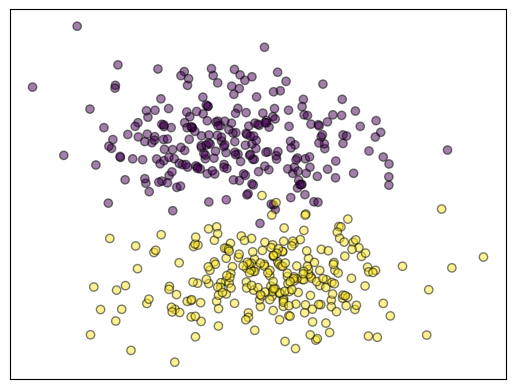

In [5]:
plot_clusters(blobs)

In [6]:
from IPython.display import display, clear_output
from time import sleep

def plot_clusters_animated(clusters, centers=None):
    fig, ax = plt.subplots()
    x, y = clusters[0][:, 0], clusters[0][:, 1]
    labels = clusters[1]
    ax.scatter(x, y, marker="o", c=labels, edgecolors="black", alpha=0.5)

    if centers is not None:
        ax.scatter(centers[:, 0], centers[:, 1], marker="x", s=100, color="red", linewidths=5)
    ax.set_xticks(())
    ax.set_yticks(())
    return fig

def kmeans_animated(X, n_clusters, centers=None, max_iters=50, pause=0.5):
    rng = np.random.default_rng(seed=42)
    if centers is None:
        # 1. pick random points from the dataset as initial centers
        # centers = X[rng.choice(len(X), n_clusters, replace=False)]

        # 2. random coordinates
        centers = np.zeros((n_clusters, X.shape[1]))
        for i in range(n_clusters):
            centers[i] += rng.normal(scale=0.1, size=X.shape[1])

    for i in range(max_iters):
        model = KMeans(n_clusters=n_clusters, init=centers, max_iter=1, n_init=1)
        model.fit(X)

        new_centers = model.cluster_centers_
        labels = model.labels_

        clear_output(wait=True)
        fig = plot_clusters_animated((X, labels), centers=new_centers)
        display(fig)
        plt.close(fig)
        sleep(pause)

        if np.allclose(centers, new_centers):
            break

        centers = new_centers

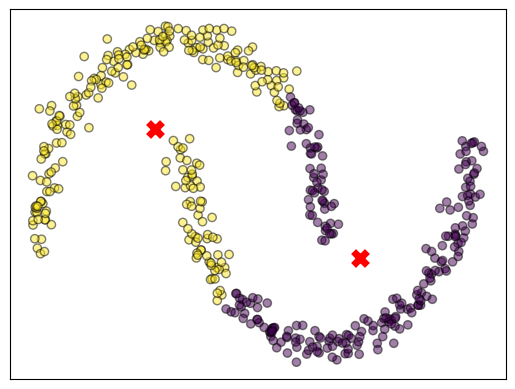

In [7]:
X = crescents[0]
k = 2

kmeans_animated(X, n_clusters=k, centers=None, max_iters=100, pause=0.75)

# Elbow method

In [ ]:
blobs = datasets.make_blobs(
    n_samples=2 * n_samples,
    n_features=10, # notice we have more than 2 features
    centers=4,
    cluster_std=1,
    random_state=0
)

# This will raise an error since we can't plot more than 2D data
plot_clusters(blobs)

ValueError: Only 2D data can be plotted.

In [9]:
inertia = {}
for c in range(2, 8):
    kmeans = KMeans(
        n_clusters=c,
        init="k-means++",
        n_init=1,
        max_iter=300,
        random_state=seed
    ).fit(blobs[0])
    inertia[c] = kmeans.inertia_

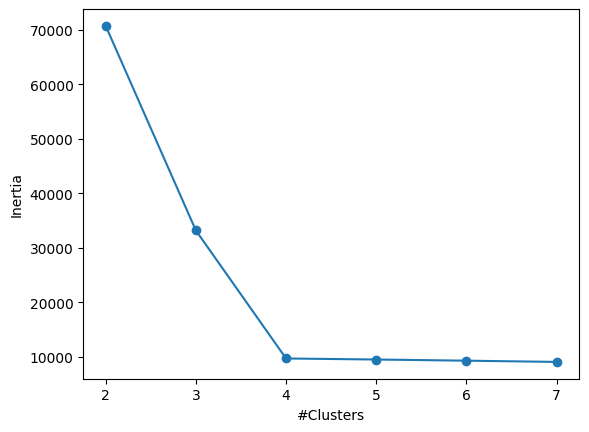

In [ ]:
plt.figure()
plt.plot(inertia.keys(), inertia.values(), marker="o")
plt.xlabel("#Clusters")
plt.ylabel("Inertia")
plt.show()

# Notice, the elbow at #clusters = 4